In [1]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score



In [2]:

from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [3]:
df = pd.read_csv("Mall_Customers.csv")

In [4]:
print(df.head())

print("\nDataset Shape:")
print(df.shape)


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape:
(200, 5)


In [5]:

X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



In [7]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)


clusters = dbscan.fit_predict(X_scaled)



In [8]:
df["Cluster"] = clusters



print("\nClustered Data:")
print(df.head())


Clustered Data:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  


In [9]:
print("\nUnique Cluster Labels:")

print(set(clusters))


print(
    "\nNumber of Noise Points:",
    list(clusters).count(-1)
)



Unique Cluster Labels:
{np.int64(0), np.int64(1), np.int64(-1)}

Number of Noise Points: 8


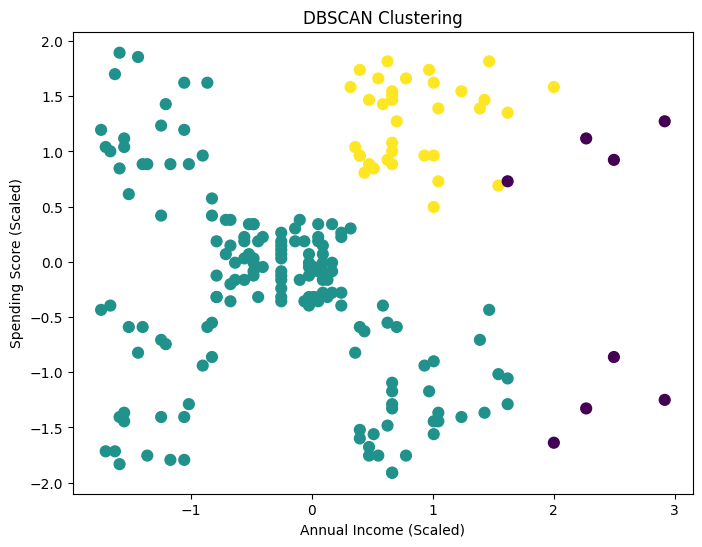

In [10]:

plt.figure(figsize=(8,6))


plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    s=60
)


plt.xlabel("Annual Income (Scaled)")

plt.ylabel("Spending Score (Scaled)")


plt.title("DBSCAN Clustering")


plt.show()

In [11]:
mask = clusters != -1


if len(set(clusters[mask])) > 1:

    silhouette = silhouette_score(
        X_scaled[mask],
        clusters[mask]
    )

    print(
        "\nDBSCAN Silhouette Score:",
        silhouette
    )

else:

    print(
        "\nDBSCAN did not create enough clusters for evaluation"
    )



DBSCAN Silhouette Score: 0.3875583892728279


In [12]:
print("\nCluster Counts:")

print(
    df["Cluster"].value_counts()
)


Cluster Counts:
Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64
